In [1]:
import mediapipe as mp
import cv2
import numpy as np
import os

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [2]:
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.3
)

In [3]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.multi_hand_landmarks[0], mp_hands.HAND_CONNECTIONS,
                              mp_drawing.DrawingSpec(color=(0, 32, 128), thickness=2, circle_radius=2),
                              mp_drawing.DrawingSpec(color=(255, 255, 255), thickness=2))

In [4]:
def extract_landmarks(results):
    all_landmarks = np.array(
        [[landmark.x, landmark.y, landmark.z] for hand_landmarks in results.multi_hand_landmarks for landmark in
         hand_landmarks.landmark]).flatten() if results.multi_hand_landmarks else np.zeros(21 * 3)
    return all_landmarks

In [5]:
def number_to_russian_letter(number):
    alphabet = 'АБВГДЕЁЖЗИЙКЛМНОПРСТУФХЦЧШЩЪЫЬЭЮЯ'
    return alphabet[number - 1] if 1 <= number <= 33 else None

In [6]:
DATA_PATH = os.path.join('./data/NewTrain')

gestures = np.array([number_to_russian_letter(int(i)) for i in os.listdir(DATA_PATH)])

sequence_length = 25

In [32]:
for subdir, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith('.mp4'):
            video_path = os.path.join(subdir, file)
            
            all_landmarks = []
            
            cap = cv2.VideoCapture(video_path)
            for frame_num in range(sequence_length):
                ret, frame = cap.read()
                if not ret:
                    break
                
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                results = hands.process(frame)
                landmarks = extract_landmarks(results)
                
                all_landmarks.append(landmarks)
            
            if len(all_landmarks) < sequence_length:
                all_landmarks.extend([np.zeros(21 * 3)] * (sequence_length - len(all_landmarks)))
            
            cap.release()
            
            all_landmarks = np.array(all_landmarks)
            
            np.save(video_path.replace('.mp4', '.npy'), all_landmarks)

In [7]:
label_map = {label:num for num, label in enumerate(gestures)}

In [8]:
label_map

{'А': 0,
 'И': 1,
 'Й': 2,
 'К': 3,
 'Л': 4,
 'М': 5,
 'Н': 6,
 'О': 7,
 'П': 8,
 'Р': 9,
 'С': 10,
 'Б': 11,
 'Т': 12,
 'У': 13,
 'Ф': 14,
 'Х': 15,
 'Ц': 16,
 'Ч': 17,
 'Ш': 18,
 'Щ': 19,
 'Ъ': 20,
 'Ы': 21,
 'В': 22,
 'Ь': 23,
 'Э': 24,
 'Ю': 25,
 'Я': 26,
 'Г': 27,
 'Д': 28,
 'Е': 29,
 'Ё': 30,
 'Ж': 31,
 'З': 32}

In [9]:
sequences, labels = [], []
for subdir, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith('.npy'):
            labels.append(label_map[number_to_russian_letter(int(subdir.split('\\')[-1]))])
            sequence = np.load(os.path.join(subdir, file))
            sequences.append(sequence)

In [10]:
X = np.array(sequences)

In [11]:
X.shape

(826, 25, 63)

In [12]:
y = to_categorical(labels).astype(int)

In [13]:
y.shape

(826, 33)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((660, 25, 63), (166, 25, 63), (660, 33), (166, 33))

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.callbacks import ModelCheckpoint

In [30]:
log_dir = os.path.join('Logs')
tensorboard = TensorBoard(log_dir=log_dir)

checkpoint = ModelCheckpoint('./best_model.keras', monitor='val_categorical_accuracy', save_best_only=True, mode='max', verbose=1)

In [31]:
model = Sequential()

model.add(Input(shape=(sequence_length, 21 * 3)))
model.add(LSTM(64, return_sequences=True, activation='relu'))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(gestures.shape[0], activation='softmax'))

In [32]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [33]:
history = model.fit(X_train, y_train, epochs=350, callbacks=[tensorboard, checkpoint], validation_data=(X_test, y_test))

Epoch 1/350
19/21 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - categorical_accuracy: 0.0233 - loss: 3.4971
Epoch 1: val_categorical_accuracy improved from -inf to 0.03614, saving model to ./best_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - categorical_accuracy: 0.0237 - loss: 3.4968 - val_categorical_accuracy: 0.0361 - val_loss: 3.5028
Epoch 2/350
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - categorical_accuracy: 0.0361 - loss: 3.4874
Epoch 2: val_categorical_accuracy improved from 0.03614 to 0.05422, saving model to ./best_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - categorical_accuracy: 0.0363 - loss: 3.4876 - val_categorical_accuracy: 0.0542 - val_loss: 3.4994
Epoch 3/350
20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - categorical_accuracy: 0.0528 - loss: 3.4894
Epoch 3: val_categorical_accuracy did not improve from 0.05422
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - categorical_accuracy: 0.0531 - loss: 3.4894 - val_categorical_accuracy: 0.0301 - val_loss: 3.5101
Epoch 4/350
20/21 ━━

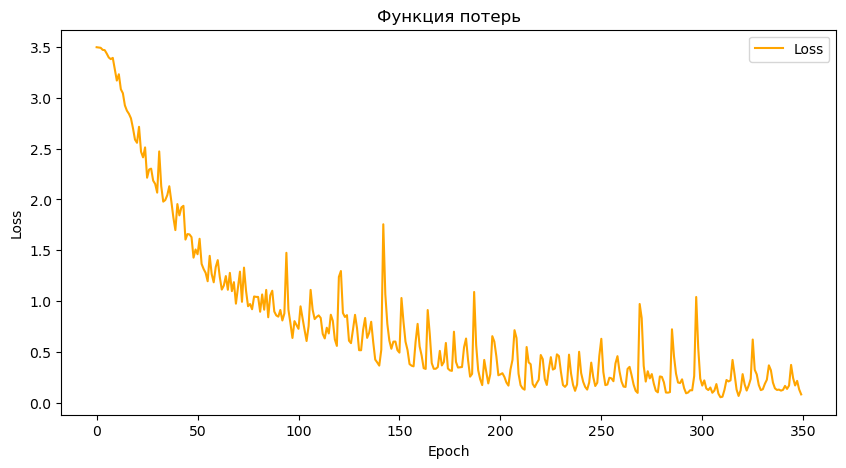

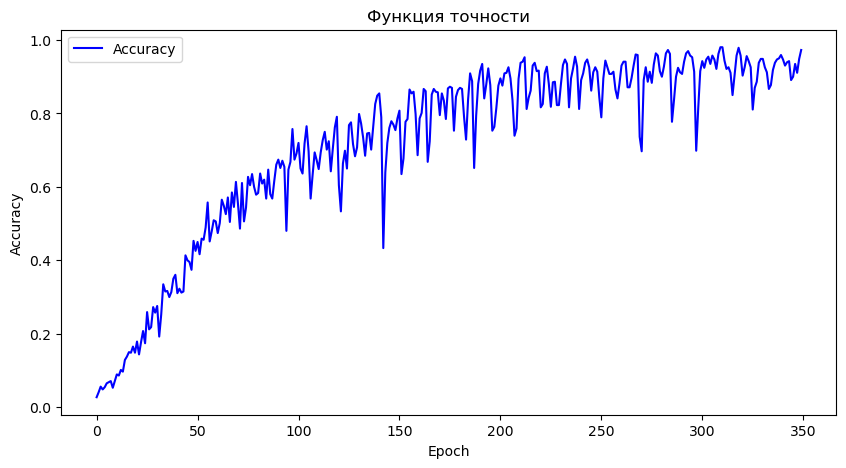

In [34]:
import matplotlib.pyplot as plt

loss_values = history.history['loss']
accuracy_values = history.history['categorical_accuracy']

plt.figure(figsize=(10,5))
plt.plot(loss_values, label='Loss', color='orange')
plt.title('Функция потерь')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('./graphics/LSTMLoss.png')
plt.show()

plt.figure(figsize=(10,5))
plt.plot(accuracy_values, label='Accuracy', color='blue')
plt.title('Функция точности')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('./graphics/LSTMAccuracy.png')
plt.show()

In [35]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 25, 64)         │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 25, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 33)             │         1,089 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 564,965 (2.16 MB)

 Trainable params: 188,321 (735.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 376,644 (1.44 MB)

In [73]:
from tensorflow.keras.models import load_model
import json

In [74]:
model = load_model('./best_model.keras')
y_hat = model.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step


In [75]:
y_true = np.argmax(y_test, axis=1).tolist()
y_pred = np.argmax(y_hat, axis=1).tolist()

with open('cm.json', 'w') as f:
    json.dump({
        'y_true': y_true,
        'y_pred': y_pred
    }, f)

In [49]:
from PIL import Image, ImageDraw, ImageFont

In [70]:
sequence = []
sentence = []
threshold = 0.9

cap = cv2.VideoCapture('./data/Test/1_7.mp4')
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(frame)
    
    cv2.rectangle(frame, (0, 0), (frame.shape[1], 50), (255, 255, 255), -1)
    
    if results.multi_hand_landmarks:
        draw_landmarks(frame, results)
        
        keypoints = extract_landmarks(results)
        sequence.append(keypoints)
        sequence = sequence[-sequence_length:]
        
        if len(sequence) == sequence_length:
            res = model.predict(np.expand_dims(sequence, axis=0), verbose = 0)[0]
            if res[np.argmax(res)] > threshold:
                gesture = gestures[np.argmax(res)]
                pil_img = Image.fromarray(frame)
                draw = ImageDraw.Draw(pil_img)
                font = ImageFont.truetype("arial.ttf", 30)
                draw.text((frame.shape[1] // 2, 10), gesture, font=font, fill=(0, 0, 0, 0))
                frame = np.array(pil_img)
                
    cv2.imshow('frame', cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()